In [1]:
import pandas as pd

# charger les données
df = pd.read_csv("../data/supermarket_sales.csv")

# afficher les premières lignes
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
df.isnull().sum()


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   str           
 1   Branch                   1000 non-null   str           
 2   City                     1000 non-null   str           
 3   Customer type            1000 non-null   str           
 4   Gender                   1000 non-null   str           
 5   Product line             1000 non-null   str           
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[us]
 11  Time                     1000 non-null   str           
 12  Payment                  1000 non-null   str  

In [ ]:
# extraire le mois
df["Month"] = df["Date"].dt.month

# extraire le jour
df["Day"] = df["Date"].dt.day

# extraire l'année
df["Year"] = df["Date"].dt.year
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day,Year
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,1,5,2019
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,3,8,2019
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,3,3,2019
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,1,27,2019
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,2,8,2019


In [ ]:
df.groupby("Month")["Sales"].sum()
df.groupby("Month")["Sales"].sum().sort_values(ascending=False)

Month
1    116291.868
3    109455.507
2     97219.374
Name: Sales, dtype: float64

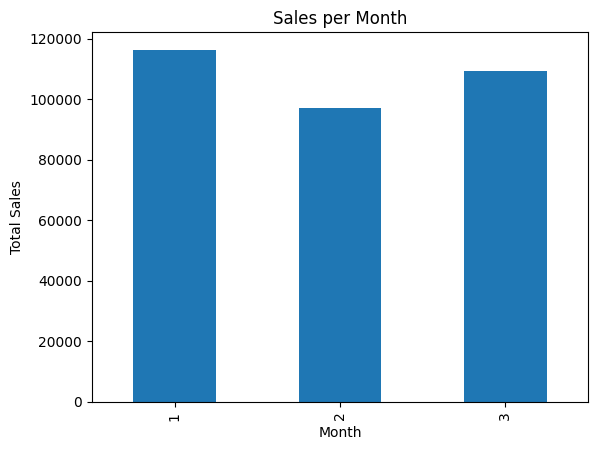

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Month")["Sales"].sum().plot(kind="bar")
plt.title("Sales per Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)


Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

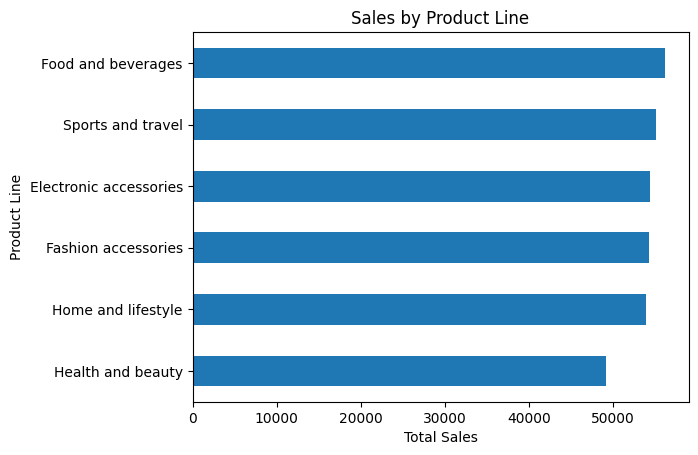

In [ ]:

df.groupby("Product line")["Sales"].sum().sort_values().plot(kind="barh")
plt.title("Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.show()

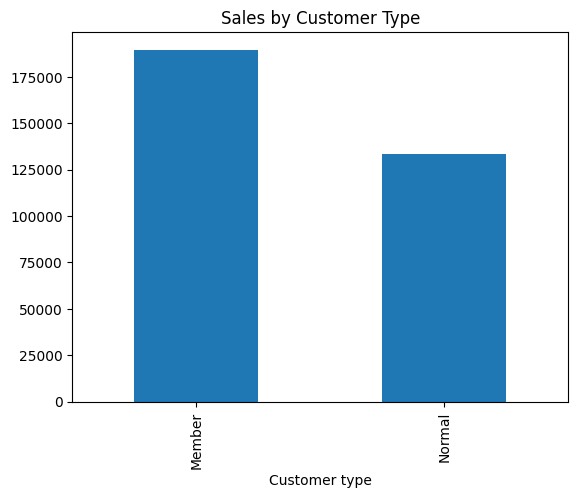

In [ ]:

df.groupby("Customer type")["Sales"].sum()
df.groupby("Customer type")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Customer Type")
plt.show()

In [ ]:
df.groupby("Gender")["Sales"].sum()

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64

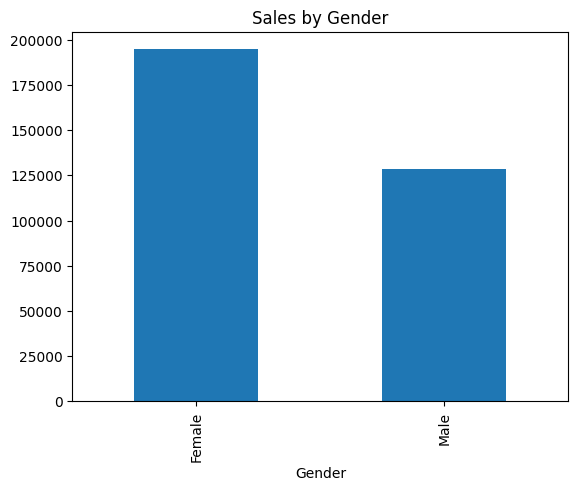

In [ ]:
df.groupby("Gender")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Gender")
plt.show()

<Axes: >

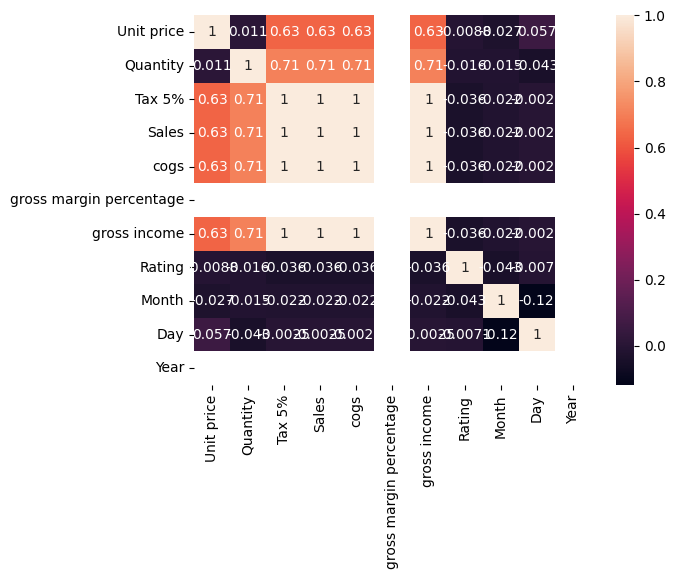

In [ ]:
df.corr(numeric_only=True)
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
X = df[["Unit price", "Quantity", "Rating", "Month"]]
y = df["Sales"]